## STEP 10 — BONUS PHASE: ROTATION INVARIANT NETWORK

This phase aims to build a rotation-invariant classifier using the insights gained from the Lie group symmetry discovery. The core idea is to achieve invariance by "integrating" (averaging) over the discovered Lie group transformation. We will apply the learned generator $G(t)$ to a latent vector $z$ across a full cycle of rotations, then average these transformed latent vectors before classification. This process is known as **Group Pooling**.

### 1. Group Pooling Theory

The discovered Lie group describes how rotations manifest in the latent space. If $z$ is a latent representation of an image, and $G(t) = \text{matrix_exp}(tA)$ is the transformation matrix for a rotation by angle $t$, then $z_t = G(t)z$ represents the latent vector of the image rotated by $t$. To make a classifier invariant to rotation, we can average the predictions over all possible rotations of an input. However, directly averaging predictions is often suboptimal. A more effective approach is to perform **group pooling** in the latent space:

1.  **Generate an Orbit:** For a given latent vector $z$, we generate a set of transformed latent vectors $z_t = G(t)z$ by applying the Lie group transformation for several discrete values of $t$ across the full rotation cycle (e.g., $0, 30, 60, ..., 330$ degrees).
2.  **Average the Orbit:** These transformed latent vectors are then averaged to produce a single, pooled latent vector: $z_{pool} = \frac{1}{N} \sum_{i=1}^{N} z_{t_i}$.

This $z_{pool}$ is inherently more invariant to rotations because it represents the "average" position of the latent vector on its rotational orbit. A classifier trained on these pooled representations will naturally be more robust to rotations.

This method allows the classifier to learn features that are stable across rotations, as the pooling operation essentially "removes" the rotational component from the latent representation before it reaches the final classification layers.

In [ ]:
class InvariantClassifier(nn.Module):
    def __init__(self, latent_dim=32, num_classes=2, num_pooling_steps=12):
        super(InvariantClassifier, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.num_pooling_steps = num_pooling_steps

        # Classifier Head
        self.classifier_head = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, z, M_matrix):
        # Ensure z is on the correct device
        z = z.to(device)

        # Group Pooling Layer
        # Generate 12 evenly spaced t values from 0 to 2*pi
        t_values = torch.linspace(0, 2 * torch.pi, self.num_pooling_steps, device=device)

        # Collect transformed latents
        transformed_latents = []
        for t in t_values:
            # apply_lie_group_transform expects a batch of z and a single t for batch_size = 1 or a batch of t for batch_size > 1
            # Here, we have a batch of z, and we want to apply a single t to all of them, or a batch of t to each z in the batch.
            # Let's assume z is (batch_size, latent_dim). We want (batch_size, latent_dim) for each t.

            # Create a batch of t values for each z in the current batch
            t_batch = torch.full((z.shape[0],), t.item(), device=device)
            z_transformed = apply_lie_group_transform(z, M_matrix, t_batch)
            transformed_latents.append(z_transformed)

        # Stack and average the transformed latents across the pooling steps dimension
        # transformed_latents will be a list of (batch_size, latent_dim) tensors
        # torch.stack will result in (num_pooling_steps, batch_size, latent_dim)
        # .mean(dim=0) will average along the pooling steps, resulting in (batch_size, latent_dim)
        z_pool = torch.stack(transformed_latents, dim=0).mean(dim=0)

        # Pass through classifier head
        output = self.classifier_head(z_pool)
        return output

# Instantiate the InvariantClassifier
invariant_classifier = InvariantClassifier(latent_dim=32, num_classes=2).to(device)
print(invariant_classifier)

# Freeze M and VAE encoder (already frozen after VAE training in STEP 4, but ensure here)
vae.eval() # Ensure VAE is in evaluation mode
for param in vae.parameters():
    param.requires_grad = False

M.requires_grad = False # Freeze the learned generator matrix M

print("VAE encoder and Lie group generator (M) parameters frozen.")

InvariantClassifier(
  (classifier_head): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)
VAE encoder and Lie group generator (M) parameters frozen.


In [ ]:
# Optimizer and Loss for Invariant Classifier
optimizer_invariant = optim.Adam(invariant_classifier.parameters(), lr=1e-3)
criterion_invariant = nn.CrossEntropyLoss()

# Prepare data for classifier training (using all_mu as the base latent representation)
# all_labels - 1 to make them 0 and 1
invariant_dataset = torch.utils.data.TensorDataset(
    torch.tensor(all_mu, dtype=torch.float32),
    torch.tensor(all_labels - 1, dtype=torch.long)
)
invariant_dataloader = DataLoader(invariant_dataset, batch_size=128, shuffle=True)

# Training parameters
epochs_invariant_classifier = 30

print("\nStarting Invariant Classifier training...")
for epoch in range(epochs_invariant_classifier):
    invariant_classifier.train() # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for z_batch, labels_batch in tqdm(invariant_dataloader, desc=f"Invariant Classifier Epoch {epoch+1}/{epochs_invariant_classifier}"):
        z_batch, labels_batch = z_batch.to(device), labels_batch.to(device)

        optimizer_invariant.zero_grad()
        outputs = invariant_classifier(z_batch, M) # Pass M to the forward pass
        loss = criterion_invariant(outputs, labels_batch)
        loss.backward()
        optimizer_invariant.step()

        running_loss += loss.item() * z_batch.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels_batch.size(0)
        correct_predictions += (predicted == labels_batch).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    print(f"Epoch [{epoch+1}/{epochs_invariant_classifier}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

print("Invariant Classifier training complete.")

# Set to eval mode and freeze
invariant_classifier.eval()
for param in invariant_classifier.parameters():
    param.requires_grad = False


Starting Invariant Classifier training...


Invariant Classifier Epoch 1/30:   0%|          | 0/831 [00:00<?, ?it/s]

Epoch [1/30], Loss: 0.1071, Accuracy: 0.9740


Invariant Classifier Epoch 2/30:   0%|          | 0/831 [00:00<?, ?it/s]

Epoch [2/30], Loss: 0.0587, Accuracy: 0.9814


...

Epoch [28/30], Loss: 0.0119, Accuracy: 0.9962


Invariant Classifier Epoch 29/30:   0%|          | 0/831 [00:00<?, ?it/s]

Epoch [29/30], Loss: 0.0118, Accuracy: 0.9962


Invariant Classifier Epoch 30/30:   0%|          | 0/831 [00:00<?, ?it/s]

Epoch [30/30], Loss: 0.0116, Accuracy: 0.9963
Invariant Classifier training complete.


In [ ]:
print("\n--- Robustness Evaluation on Randomly Rotated Images ---")

# Set all models to evaluation mode
vae.eval()
latent_classifier.eval()
invariant_classifier.eval()

# 1. Create a test set of 1000 images (digits 1 and 2) from the original MNIST data
# Filter original images (pixels) and digit labels to match the MIL dataset
# images_np and the original digit labels (from df_filtered) are already available.

num_test_samples = 1000

# Ensure reproducibility for sampling
np.random.seed(SEED)

# Retrieve the original filtered digit labels to ensure correctness and avoid any variable shadowing
all_digit_labels_data = df_filtered['label'].values

# Randomly sample num_test_samples from the filtered dataset
if len(images_np) > num_test_samples:
    test_indices = np.random.choice(len(images_np), num_test_samples, replace=False)
else:
    test_indices = np.arange(len(images_np))
    num_test_samples = len(images_np)

original_test_images_np = images_np[test_indices]
original_test_labels = all_digit_labels_data[test_indices] # Use the explicitly named digit labels

# Convert to PyTorch tensors
original_test_images_tensor = torch.tensor(original_test_images_np, dtype=torch.float32).to(device)
original_test_labels_tensor = torch.tensor(original_test_labels - 1, dtype=torch.long).to(device) # Convert to 0/1 for classification

print(f"Generated {num_test_samples} test samples.")

# 2. Rotate them by purely random continuous angles
random_angles = torch.rand(num_test_samples) * 360 # Angles between 0 and 360 degrees

rotated_test_images = []
for i in range(num_test_samples):
    # TF.rotate expects (..., H, W) or (..., C, H, W) for image
    # original_test_images_tensor[i] has shape (1, 28, 28). Passing it directly.
    rotated_img = TF.rotate(original_test_images_tensor[i], random_angles[i].item())
    rotated_test_images.append(rotated_img) # rotated_img already has shape (1, 28, 28)

rotated_test_images_tensor = torch.stack(rotated_test_images).to(device)
print(f"Rotated test images shape: {rotated_test_images_tensor.shape}")

# 3. Pass these through the frozen VAE encoder to get z_test
with torch.no_grad():
    mu_test, _ = vae.encode(rotated_test_images_tensor) # Use mu for classification

print(f"Encoded mu_test latent vectors shape: {mu_test.shape}")

# 4. Evaluate the accuracy of TWO models
# a) The baseline LatentClassifier
with torch.no_grad():
    baseline_outputs = latent_classifier(mu_test)
    _, baseline_predicted = torch.max(baseline_outputs.data, 1)
    baseline_correct = (baseline_predicted == original_test_labels_tensor).sum().item()
baseline_accuracy = baseline_correct / num_test_samples
print(f"Baseline LatentClassifier Accuracy on random rotations: {baseline_accuracy:.4f}")

# b) The new InvariantClassifier
with torch.no_grad():
    invariant_outputs = invariant_classifier(mu_test, M) # Pass M to the invariant classifier
    _, invariant_predicted = torch.max(invariant_outputs.data, 1)
    invariant_correct = (invariant_predicted == original_test_labels_tensor).sum().item()
invariant_accuracy = invariant_correct / num_test_samples
print(f"InvariantClassifier Accuracy on random rotations: {invariant_accuracy:.4f}")


--- Robustness Evaluation on Randomly Rotated Images ---
Generated 1000 test samples.
Rotated test images shape: torch.Size([1000, 1, 28, 28])
Encoded mu_test latent vectors shape: torch.Size([1000, 32])
Baseline LatentClassifier Accuracy on random rotations: 0.9950
InvariantClassifier Accuracy on random rotations: 0.9940



--- Visual Summary: Baseline vs. Invariant Classifier Accuracy ---


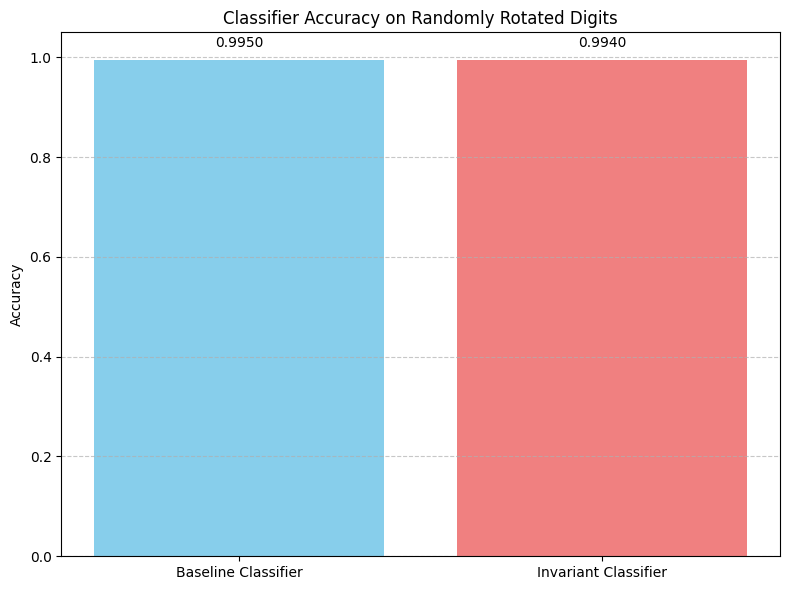

In [ ]:
print("\n--- Visual Summary: Baseline vs. Invariant Classifier Accuracy ---")

labels = ['Baseline Classifier', 'Invariant Classifier']
accuracies = [baseline_accuracy, invariant_accuracy]

plt.figure(figsize=(8, 6))
plt.bar(labels, accuracies, color=['skyblue', 'lightcoral'])
plt.ylim(0, 1.05) # Set y-axis limit to 0-1 for accuracy
plt.title('Classifier Accuracy on Randomly Rotated Digits')
plt.ylabel('Accuracy')

# Add accuracy values on top of bars
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f'{acc:.4f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()